<a href="https://colab.research.google.com/github/gapalfaro-cmyk/gapalfaro-cmyk-Proyecto-de-fin-de-modulo-7.3---Alfaro-Badillo-Cruz-Perez-Rupit-/blob/main/Tarea3_Alfaro_Badillo_Cruz_Perez_Rupit_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 3

Vamos a usar una base de datos de rentas de bicicletas por hora `Bike Sharing Demand` disponible en Scikit-learn. Tenemos datos de la forma

$$(x_t, y_t),$$

donde $x_t$ es un vector de características, $y_t$ el número de biciletas rentadas al tiempo $t$. Aplicar el algoritmo *Online Gradient Descent* a esta base de datos y evaluar su Regret.

1. Descripción del problema
2. Metodología
3. Resultados, tablas, gráficas
4. Conclusiones

## Descripción del problema
Aplicar el OGD (*Online Gradient Descent*) a esta base de datos de rentas de bicicletas por hora `Bike Sharing Demand`.

## Metodología
Aplicaremos el algoritmo Online Gradient Descent (OGD) para el problema de regresión lineal. Se utilizará la pérdida cuadrática:$$\ell_t(w) = (w^T x_t - y_t)^2$$

En cada paso, actualizaremos el vector de pesos $w$ en la dirección opuesta al gradiente de la función de pérdida con respecto a la observación actual:$$w_{t+1} = w_t - \eta \cdot \nabla \ell_t(w_t)$$

Donde $$\nabla \ell_t(w_t) = 2(w_t^T x_t - y_t)x_t$$ y $$\eta$$ es la tasa de aprendizaje.Para calcular el Regret en el tiempo $t$, compararemos la pérdida del algoritmo con la pérdida del Mejor Predictor Fijo $w^*_t$.

Dicho predictor se calculará resolviendo el sistema de Mínimos Cuadrados Ordinarios (OLS) exclusivamente para las observaciones reveladas en el prefijo temporal de $1$ a $t$. Dado que las variables reales tienen magnitudes variadas, es estrictamente necesario estandarizar $X$ y $y$ antes del bucle para garantizar la convergencia del gradiente.

## Programación (resultados, tablas y gráficas)...

In [24]:
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.optimize import minimize
from scipy.special import expit

bike = fetch_openml(
    name="Bike_Sharing_Demand",
    version=2,
    as_frame=True
)

In [25]:
X = bike.data
y = bike.target

df = bike.frame
display(df.head(40))
display(df.info())
display(df["count"].value_counts())

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0000,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0000,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0000,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0000,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0000,1
5,spring,0,1,5,False,6,False,misty,9.84,12.880,0.75,6.0032,1
6,spring,0,1,6,False,6,False,clear,9.02,13.635,0.80,0.0000,2
7,spring,0,1,7,False,6,False,clear,8.20,12.880,0.86,0.0000,3
8,spring,0,1,8,False,6,False,clear,9.84,14.395,0.75,0.0000,8
9,spring,0,1,9,False,6,False,clear,13.12,17.425,0.76,0.0000,14


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   season      17379 non-null  category
 1   year        17379 non-null  int64   
 2   month       17379 non-null  int64   
 3   hour        17379 non-null  int64   
 4   holiday     17379 non-null  category
 5   weekday     17379 non-null  int64   
 6   workingday  17379 non-null  category
 7   weather     17379 non-null  category
 8   temp        17379 non-null  float64 
 9   feel_temp   17379 non-null  float64 
 10  humidity    17379 non-null  float64 
 11  windspeed   17379 non-null  float64 
 12  count       17379 non-null  int64   
dtypes: category(4), float64(4), int64(5)
memory usage: 1.3 MB


None

,count
count,
5,260
6,236
4,231
3,224
2,208
...,...
938,1
826,1
963,1


In [27]:
y = df["count"]

X = df.drop(columns="count")

X.head()

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0


In [28]:
from sklearn.preprocessing import OneHotEncoder

categorical_cols = [
    "season",
    "holiday",
    "workingday",
    "weather"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=False
)

X_encoded.head()

,year,month,hour,weekday,temp,feel_temp,humidity,windspeed,season_fall,season_spring,season_summer,season_winter,holiday_False,holiday_True,workingday_False,workingday_True,weather_clear,weather_heavy_rain,weather_misty,weather_rain
0,0,1,0,6,9.84,14.395,0.81,0.0,False,True,False,False,True,False,True,False,True,False,False,False
1,0,1,1,6,9.02,13.635,0.80,0.0,False,True,False,False,True,False,True,False,True,False,False,False
2,0,1,2,6,9.02,13.635,0.80,0.0,False,True,False,False,True,False,True,False,True,False,False,False
3,0,1,3,6,9.84,14.395,0.75,0.0,False,True,False,False,True,False,True,False,True,False,False,False
4,0,1,4,6,9.84,14.395,0.75,0.0,False,True,False,False,True,False,True,False,True,False,False,False


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler

print("Descargando dataset 'Bike Sharing Demand'...")
bike_data = fetch_openml(name='Bike_Sharing_Demand', version=2, as_frame=True, parser="auto")
print("Terminado...")

df = bike_data.frame # OJO! Tarda!

print("\nDataset completamente limpio!")
display(df.isna().sum())

Descargando dataset 'Bike Sharing Demand'...
Terminado...

Dataset completamente limpio!


,0
season,0
year,0
month,0
hour,0
holiday,0
weekday,0
workingday,0
weather,0
temp,0
feel_temp,0


#### EDA sencillito!

In [30]:
def resumen_df(df, nombre="DataFrame"):
    print(f"Resumen de {nombre}:")
    print(f"- Filas: {df.shape[0]}")
    print(f"- Columnas: {df.shape[1]}")
    print("- Nombres de columnas:")
    for col in df.columns:
        print(f"   • {col}")

resumen_df(df, "Bike Sharing Demand")

Resumen de Bike Sharing Demand:
- Filas: 17379
- Columnas: 13
- Nombres de columnas:
   • season
   • year
   • month
   • hour
   • holiday
   • weekday
   • workingday
   • weather
   • temp
   • feel_temp
   • humidity
   • windspeed
   • count


In [31]:
num_columns = ["temp", "feel_temp", "humidity", "windspeed", "count"]
categorical_columns = ['season', 'holiday', 'workingday', 'weather']

display(df[num_columns].describe())

,temp,feel_temp,humidity,windspeed,count
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,20.376474,23.788755,0.627229,12.736540,189.463088
std,7.894801,8.592511,0.192930,8.196795,181.387599
min,0.820000,0.000000,0.000000,0.000000,1.000000
25%,13.940000,16.665000,0.480000,7.001500,40.000000
50%,20.500000,24.240000,0.630000,12.998000,142.000000
75%,27.060000,31.060000,0.780000,16.997900,281.000000
max,41.000000,50.000000,1.000000,56.996900,977.000000


In [32]:
cols = ["season", "year", "hour", "holiday", "weekday", "workingday", "weather"]

for i in cols:
    print("Columna: ", i)
    display(df[i].unique())
    print("\n")

Columna:  season


['spring', 'summer', 'fall', 'winter']
Categories (4, object): ['fall', 'spring', 'summer', 'winter']



Columna:  year


array([0, 1])



Columna:  hour


...

array([6, 0, 1, 2, 3, 4, 5])



Columna:  workingday


['False', 'True']
Categories (2, object): ['False', 'True']



Columna:  weather


['clear', 'misty', 'rain', 'heavy_rain']
Categories (4, object): ['clear', 'heavy_rain', 'misty', 'rain']

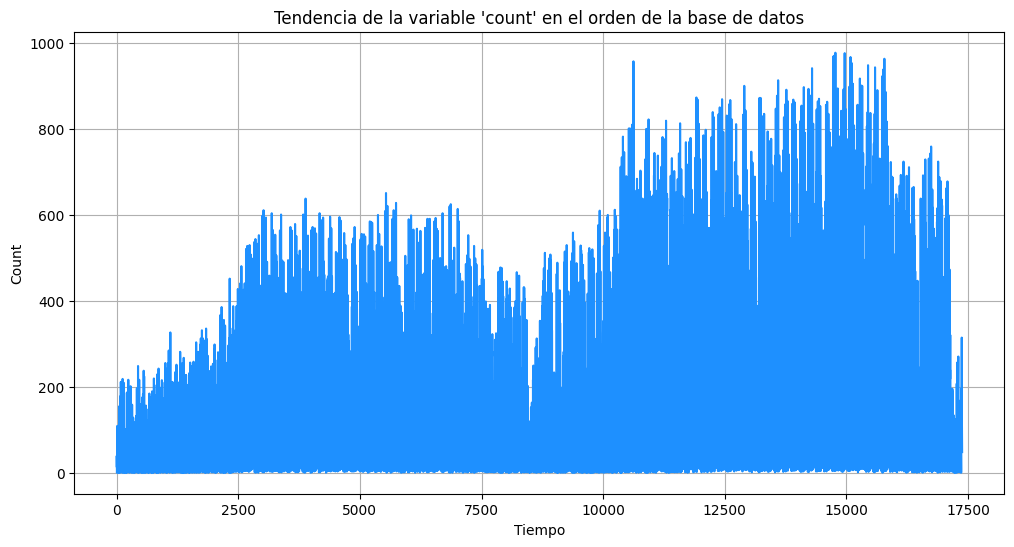

In [33]:
# Numero de bicicletas por Hora
plt.figure(figsize=(12,6))
plt.plot(df.index, df['count'], color='dodgerblue')
plt.title("Tendencia de la variable 'count' en el orden de la base de datos")
plt.xlabel("Tiempo")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [38]:
# == Codificación y Escalamiento de variables ==
# Creamos una copia del dataframe para aplicar one-hot encoding
df_processed = df.copy()
df_processed = pd.get_dummies(df_processed, columns=categorical_columns, drop_first=False)
#
# Seleccionamos las columnas predictoras del dataframe procesado
# Excluimos la columna objetivo 'count' y el tiempo en años 'year'
predictor_columns = [col for col in df_processed.columns if col != ['count', 'year', 'month']] #, 'weekday' ,  'hour' * con estas regresa a ser dos escalones
X_raw = df_processed[predictor_columns].astype(float).values
y_raw = df['count'].astype(float).values
#
# Estandarización obligatoria para evitar explosión de gradiente con MSE
X = StandardScaler().fit_transform(X_raw)
y = StandardScaler().fit_transform(y_raw.reshape(-1, 1)).flatten()

Entrenando OGD...


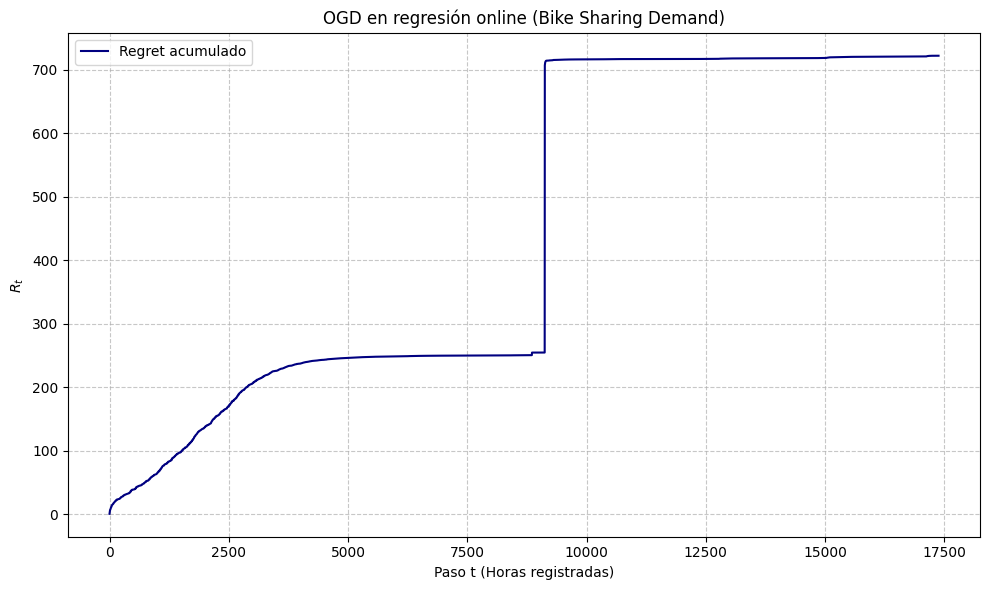

In [39]:
n = X.shape[0]

w = np.zeros(X.shape[1])
eta = 0.001

cumulative_online_loss = 0.0
online_losses = []
regret_curve = []

print("Entrenando OGD...")

for t in range(n):
    x_t = X[t]
    y_t = y[t]

    # Predecir antes de actualizar
    pred_t = np.dot(w, x_t)

    # Sufrir la pérdida
    loss_t = (pred_t - y_t) ** 2
    online_losses.append(loss_t)
    cumulative_online_loss += loss_t

    # Mejor predictor fijo para las observaciones 1,...,t
    X_prefix = X[:t + 1]
    y_prefix = y[:t + 1]

    w_star_t = np.linalg.lstsq(
        X_prefix,
        y_prefix,
        rcond=None
    )[0]

    # Oráculo
    best_fixed_loss = np.sum(
        (X_prefix @ w_star_t - y_prefix) ** 2
    )

    # Regret hasta el tiempo t
    regret_t = cumulative_online_loss - best_fixed_loss
    regret_curve.append(regret_t)

    # Actualizar después de observar la pérdida
    grad = 2 * (pred_t - y_t) * x_t
    w = w - eta * grad

# Visualización
plt.figure(figsize=(10, 6))
plt.plot(regret_curve, color='navy', label="Regret acumulado")
plt.xlabel("Paso t (Horas registradas)")
plt.ylabel(r"$R_t$")
plt.title("OGD en regresión online (Bike Sharing Demand)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.savefig('OGD_2.pdf', dpi=300)
plt.show()


## Conclusiones

En la gráfica de Regret Acumulado observamos que logra estabilizarse (aplanarse) durante el transcurso del Año 0, lo cual demuestra que el modelo OGD aprendió eficazmente los patrones predictivos iniciales de la demanda. No obstante, se observa un salto abrupto en la transición hacia el Año 1. De acuerdo con el Análisis Exploratorio de Datos (EDA), este salto no responde a un fallo del algoritmo, sino a un Concept Drift, el servicio de renta de bicicletas incrementó sustancialmente el volumen total de rentas por hora. El salto en el regret representa el costo de penalización temporal que el algoritmo pagó mientras su lógica secuencial se enfrentaba a esta nueva realidad de mercado. Finalmente, la re-estabilización (aplanamiento posterior) de la curva valida la robustez del modelo OGD, confirmando su capacidad de auto-ajuste y aprendizaje continuo ante entornos dinámicos no estacionarios.

Se probó entrenar el modelo de regresión, quitando y aumentando las diferentes variables relacionadas con la temporalidad (año, mes, hora, día de la semana, etc. ) y los resultados son similares, aunque si fue necesario eliminar estas variables de la regresión para tener un modelo correcto.
